# part1_eda — Raw data exploratory analysis
Read-only EDA of `dataset/Sample_Data.xlsx`: nothing is cleaned here, the goal is to document the raw state of the data and decide the ETL treatment.
Results: `part1_eda/v1_eda_results.xlsx` (8 sheets) and `part1_eda/figures/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

# Layout: <repo>/dataset/Sample_Data.xlsx   (local only, not in git)
#         <repo>/part1_eda/                    (output folder, created by this notebook)
HERE = Path.cwd()
DATA = HERE / "dataset" / "Sample_Data.xlsx"
OUT = HERE / "part1_eda"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)   # output folders are created here

df = pd.read_excel(DATA)
NUM = [c for c in df.columns if c not in ("Week", "Product")]

def section(title):
    print(f"\n{'=' * 80}\n{title}\n{'=' * 80}")

RESULTS = {}   # sheet name -> DataFrame, written to one Excel file at the end

def save(t, name):
    RESULTS[name.replace(".csv", "")] = t.reset_index()

## 1. SHAPE / DTYPES

In [2]:
section("1. SHAPE / DTYPES")
print(df.shape, "| expected 30 products x 260 weeks =", 30 * 260)
print(df.dtypes.to_string())


1. SHAPE / DTYPES
(7839, 13) | expected 30 products x 260 weeks = 7800
Week                          int64
Product                         str
Sales_Units                 float64
Cost_of_Goods_Sold_COGS     float64
Inventory_Level               int64
Demand_Forecast             float64
Price_Per_Unit              float64
Gross_Profit                float64
Operating_Profit            float64
Revenue                     float64
Inventory_Turnover_Ratio    float64
Gross_Profit_Margin         float64
Revenue_Growth              float64


## 2. MISSING VALUES

In [3]:
section("2. MISSING VALUES")
miss = pd.DataFrame({"n_missing": df.isna().sum(), "pct": (df.isna().mean() * 100).round(2)})
print(miss.to_string()); save(miss, "missing_values.csv")
print("rows with >=1 missing:", df.isna().any(axis=1).sum())


2. MISSING VALUES
                          n_missing   pct
Week                              0  0.00
Product                           0  0.00
Sales_Units                      16  0.20
Cost_of_Goods_Sold_COGS           0  0.00
Inventory_Level                   0  0.00
Demand_Forecast                 609  7.77
Price_Per_Unit                    0  0.00
Gross_Profit                      0  0.00
Operating_Profit                  0  0.00
Revenue                           0  0.00
Inventory_Turnover_Ratio          0  0.00
Gross_Profit_Margin               0  0.00
Revenue_Growth                    0  0.00
rows with >=1 missing: 624


## 3. PRODUCT NAMES

In [4]:
section("3. PRODUCT NAMES")
pc = df["Product"].value_counts(dropna=False).sort_index()
print(pc.to_string()); save(pc.to_frame("rows"), "rows_per_product.csv")
print("n unique raw names:", df["Product"].nunique(dropna=False))
norm = df["Product"].astype(str).str.strip().str.lower().str.replace(r"\s+", " ", regex=True)
print("n unique after trim/lower/whitespace-collapse:", norm.nunique())
print("names with leading/trailing/double whitespace:",
      int((df["Product"].astype(str) != df["Product"].astype(str).str.strip()).sum()))
print("names with inconsistent case vs. normalised form:")
grp = df.assign(n=norm).groupby("n")["Product"].unique()
print(grp[grp.apply(len) > 1].to_string())


3. PRODUCT NAMES
Product
Barley                   260
Canned Tomatoes          260
Canned Tuna              260
Chickpeas                261
Cocoa Powder             261
Coffee - Arabica         261
Coffee - Robusta         262
Corn                     260
Flour - All Purpose      263
Lentils - Green          261
Lentils - Red            262
Milk Powder - Skimmed    260
Milk Powder - Whole      260
Oats                     262
Palm Oil                 261
Pasta - Spaghetti        262
Rice - Basmati           263
Rice - White             262
Salt - Iodized           263
Soybean Oil              262
Spices - Black Pepper    263
Spices - Turmeric        262
Sugar - Raw Brown        260
Sugar - White Refined    262
Sunflower Oil            260
Tea - Black Ceylon       260
Tea - Green              261
Wheat - Hard Red         262
Wheat - Soft             261
Yeast - Dry              262
n unique raw names: 30
n unique after trim/lower/whitespace-collapse: 30
names with leading/trailing/dou

## 4. DUPLICATES

In [5]:
section("4. DUPLICATES")
print("exact duplicate rows:", df.duplicated().sum())
print("duplicate (Week, Product) keys:", df.duplicated(["Week", "Product"]).sum())
dk = df[df.duplicated(["Week", "Product"], keep=False)].sort_values(["Product", "Week"])
print("rows involved in key duplication:", len(dk))
print("key-duplicates that are NOT exact copies:", dk.drop_duplicates().duplicated(["Week", "Product"]).sum())
save(dk, "duplicate_rows.csv")
print(dk.head(12).to_string())


4. DUPLICATES
exact duplicate rows: 39
duplicate (Week, Product) keys: 39
rows involved in key duplication: 78
key-duplicates that are NOT exact copies: 0
      Week              Product  Sales_Units  Cost_of_Goods_Sold_COGS  Inventory_Level  Demand_Forecast  Price_Per_Unit  Gross_Profit  Operating_Profit   Revenue  Inventory_Turnover_Ratio  Gross_Profit_Margin  Revenue_Growth
3636   241            Chickpeas        986.0                    14.45            60745           1072.0           18.26       3756.66           1905.41  18004.36                      0.02               0.2087          0.1475
3637   241            Chickpeas        986.0                    14.45            60745           1072.0           18.26       3756.66           1905.41  18004.36                      0.02               0.2087          0.1475
5416   196         Cocoa Powder       1106.0                    33.32             2500           1418.0           43.11      10827.74           5999.99  47679.66        

## 5. WEEK COVERAGE

In [6]:
section("5. WEEK COVERAGE")
print("Week min/max:", df["Week"].min(), df["Week"].max(), "| n unique:", df["Week"].nunique())
cov = df.drop_duplicates(["Week", "Product"]).groupby("Product")["Week"].agg(["count", "min", "max"])
cov["missing_weeks"] = 260 - cov["count"]
print(cov.to_string()); save(cov, "week_coverage.csv")
gaps = {p: sorted(set(range(1, 261)) - set(g["Week"])) for p, g in df.groupby("Product")}
gaps = {p: v for p, v in gaps.items() if v}
print("products with missing weeks:", {p: v[:10] for p, v in gaps.items()})


5. WEEK COVERAGE
Week min/max: 1 260 | n unique: 260
                       count  min  max  missing_weeks
Product                                              
Barley                   260    1  260              0
Canned Tomatoes          260    1  260              0
Canned Tuna              260    1  260              0
Chickpeas                260    1  260              0
Cocoa Powder             260    1  260              0
Coffee - Arabica         260    1  260              0
Coffee - Robusta         260    1  260              0
Corn                     260    1  260              0
Flour - All Purpose      260    1  260              0
Lentils - Green          260    1  260              0
Lentils - Red            260    1  260              0
Milk Powder - Skimmed    260    1  260              0
Milk Powder - Whole      260    1  260              0
Oats                     260    1  260              0
Palm Oil                 260    1  260              0
Pasta - Spaghetti        260

## 6. DESCRIPTIVE STATS (raw)

In [7]:
section("6. DESCRIPTIVE STATS (raw)")
desc = df[NUM].describe(percentiles=[.01, .05, .5, .95, .99]).T
print(desc.round(3).to_string()); save(desc, "describe.csv")


6. DESCRIPTIVE STATS (raw)


                           count       mean        std     min       1%       5%        50%         95%         99%         max
Sales_Units               7823.0   1247.990    809.602    0.00    0.000    0.000   1500.000    2500.000    2500.000    3147.000
Cost_of_Goods_Sold_COGS   7839.0     24.744     12.500    5.53    5.864    7.100     23.290      47.433      49.370      50.870
Inventory_Level           7839.0  14950.271  35359.293    0.00    0.000    0.000   2500.000  106198.500  169733.420  201836.000
Demand_Forecast           7230.0   2049.301    893.680  297.00  422.000  588.450   2066.000    3556.100    4093.000    4910.000
Price_Per_Unit            7839.0     31.543     15.979    6.84    7.400    9.019     29.530      59.713      64.266      67.630
Gross_Profit              7839.0   8699.481   8001.518    0.00    0.000    0.000   6738.060   24540.937   31884.759   41975.000
Operating_Profit          7839.0   4733.535   4653.285    0.00    0.000    0.000   3527.940   14093.615 

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


## 7. IMPOSSIBLE / SUSPICIOUS VALUES

In [8]:
section("7. IMPOSSIBLE / SUSPICIOUS VALUES")
for c in ["Sales_Units", "Cost_of_Goods_Sold_COGS", "Inventory_Level", "Price_Per_Unit", "Revenue", "Demand_Forecast"]:
    print(f"{c:28s} <0: {(df[c] < 0).sum():4d} | ==0: {(df[c] == 0).sum():4d}")
print("Price < COGS rows (negative unit margin):", (df.Price_Per_Unit < df.Cost_of_Goods_Sold_COGS).sum())
print("Sales_Units > Inventory_Level:", (df.Sales_Units > df.Inventory_Level).sum())
print("Sales_Units non-integer:", int(((df.Sales_Units.dropna() % 1) != 0).sum()))
print("Operating_Profit > Gross_Profit:", (df.Operating_Profit > df.Gross_Profit).sum())


7. IMPOSSIBLE / SUSPICIOUS VALUES
Sales_Units                  <0:    0 | ==0: 1333
Cost_of_Goods_Sold_COGS      <0:    0 | ==0:    0
Inventory_Level              <0:    0 | ==0: 1341
Price_Per_Unit               <0:    0 | ==0:    0
Revenue                      <0:    0 | ==0: 1336
Demand_Forecast              <0:    0 | ==0:    0
Price < COGS rows (negative unit margin): 0
Sales_Units > Inventory_Level: 1931
Sales_Units non-integer: 0
Operating_Profit > Gross_Profit: 0


## 8. OUTLIERS (per-product robust z-score, |z|>4 using median/MAD; plus global IQR 3x)

In [9]:
section("8. OUTLIERS (per-product robust z-score, |z|>4 using median/MAD; plus global IQR 3x)")
rows = []
for c in ["Sales_Units", "Cost_of_Goods_Sold_COGS", "Inventory_Level", "Demand_Forecast", "Price_Per_Unit"]:
    med = df.groupby("Product")[c].transform("median")
    mad = df.assign(d=(df[c] - med).abs()).groupby("Product")["d"].transform("median")
    z = 0.6745 * (df[c] - med) / mad.replace(0, np.nan)
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    glob = ((df[c] < q1 - 3 * iqr) | (df[c] > q3 + 3 * iqr)).sum()
    rows.append({"column": c, "robust_z>4": int((z.abs() > 4).sum()), "global_IQR3x": int(glob)})
    df[f"{c}__rz"] = z
out = pd.DataFrame(rows).set_index("column"); print(out.to_string()); save(out, "outlier_counts.csv")
top = df.loc[df[[f"{c}__rz" for c in ["Sales_Units", "Cost_of_Goods_Sold_COGS", "Inventory_Level", "Demand_Forecast", "Price_Per_Unit"]]].abs().max(axis=1).nlargest(15).index,
             ["Week", "Product", "Sales_Units", "Cost_of_Goods_Sold_COGS", "Inventory_Level", "Demand_Forecast", "Price_Per_Unit"]]
print("\nmost extreme rows:\n", top.to_string()); save(top, "top_outliers.csv")
df = df.drop(columns=[c for c in df.columns if c.endswith("__rz")])


8. OUTLIERS (per-product robust z-score, |z|>4 using median/MAD; plus global IQR 3x)
                         robust_z>4  global_IQR3x
column                                           
Sales_Units                      23             0
Cost_of_Goods_Sold_COGS           1             0
Inventory_Level                  15          1349
Demand_Forecast                   1             0
Price_Per_Unit                    0             0

most extreme rows:
       Week              Product  Sales_Units  Cost_of_Goods_Sold_COGS  Inventory_Level  Demand_Forecast  Price_Per_Unit
3130   256        Lentils - Red       1395.0                    47.85             9722           1416.0           60.00
3129   255        Lentils - Red       1668.0                    48.84             9617           1595.0           64.78
3133   259        Lentils - Red       1949.0                    49.12             9456           1892.0           64.78
3131   257        Lentils - Red       1817.0                   

## 9. DERIVED-COLUMN CONSISTENCY (are given formulas reproducible?)

In [10]:
section("9. DERIVED-COLUMN CONSISTENCY (are given formulas reproducible?)")
d = df.dropna(subset=["Sales_Units"]).copy()
d["rev_calc"] = d.Sales_Units * d.Price_Per_Unit
d["gp_calc"] = d.Revenue - d.Sales_Units * d.Cost_of_Goods_Sold_COGS
d["gpm_calc"] = d.Gross_Profit / d.Revenue
d["it_a"] = d.Sales_Units / d.Inventory_Level
d["it_b"] = d.Sales_Units * d.Cost_of_Goods_Sold_COGS / d.Inventory_Level
d = d.sort_values(["Product", "Week"])
d["rg_calc"] = d.groupby("Product")["Revenue"].pct_change().fillna(0)
tests = {
    "Revenue = Sales*Price": (d.Revenue, d.rev_calc),
    "Gross_Profit = Revenue - Sales*COGS": (d.Gross_Profit, d.gp_calc),
    "GPM = GP/Revenue": (d.Gross_Profit_Margin, d.gpm_calc),
    "Turnover = Sales/Inventory": (d.Inventory_Turnover_Ratio, d.it_a),
    "Turnover = Sales*COGS/Inventory": (d.Inventory_Turnover_Ratio, d.it_b),
    "Rev_Growth = pct_change(Revenue)": (d.Revenue_Growth, d.rg_calc),
}
res = []
for k, (a, b) in tests.items():
    m = a.notna() & b.notna()
    err = (a[m] - b[m]).abs()
    res.append({"test": k, "n": int(m.sum()), "median_abs_err": err.median(), "p99_abs_err": err.quantile(.99),
                "pct_within_1%_rel": round(100 * (err <= 0.01 * b[m].abs().clip(lower=1e-9)).mean(), 1)})
res = pd.DataFrame(res).set_index("test"); print(res.round(4).to_string()); save(res, "formula_checks.csv")
print("\nCorr Demand_Forecast vs Sales_Units:", round(d.Demand_Forecast.corr(d.Sales_Units), 3))
fe = (d.Demand_Forecast - d.Sales_Units).abs() / d.Sales_Units
print("Baseline forecast MAPE on raw data (%):", round(100 * fe.mean(), 2), "| median:", round(100 * fe.median(), 2))


9. DERIVED-COLUMN CONSISTENCY (are given formulas reproducible?)
                                        n  median_abs_err  p99_abs_err  pct_within_1%_rel
test                                                                                     
Revenue = Sales*Price                7823          0.0000          0.0              100.0
Gross_Profit = Revenue - Sales*COGS  7823          0.0000          0.0              100.0
GPM = GP/Revenue                     6490          0.0000          0.0              100.0
Turnover = Sales/Inventory           7392          0.0474          NaN               35.3
Turnover = Sales*COGS/Inventory      7392         10.8265          NaN               24.4
Rev_Growth = pct_change(Revenue)     7823          0.0000          0.0               87.1



Corr Demand_Forecast vs Sales_Units: 0.208
Baseline forecast MAPE on raw data (%): inf | median: 17.52


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


## 10. PER-PRODUCT SUMMARY

In [11]:
section("10. PER-PRODUCT SUMMARY")
ps = df.groupby("Product").agg(rows=("Week", "size"), units_mean=("Sales_Units", "mean"), units_cv=("Sales_Units", lambda s: s.std() / s.mean()),
                                cogs_mean=("Cost_of_Goods_Sold_COGS", "mean"), price_mean=("Price_Per_Unit", "mean"),
                                inv_mean=("Inventory_Level", "mean"), rev_total=("Revenue", "sum"))
print(ps.round(2).to_string()); save(ps, "product_summary.csv")


10. PER-PRODUCT SUMMARY
                       rows  units_mean  units_cv  cogs_mean  price_mean   inv_mean    rev_total
Product                                                                                         
Barley                  260     1334.63      0.69       5.93        7.56    1404.22   2631702.04
Canned Tomatoes         260     1314.76      0.67      18.12       23.05    1577.68   7942141.54
Canned Tuna             260     1338.14      0.73      11.27       14.38    1423.54   5013084.42
Chickpeas               261     1038.68      0.19      14.57       18.63   33954.87   5048426.60
Cocoa Powder            261     1396.31      0.50      32.52       41.45    2564.33  15125713.14
Coffee - Arabica        261     1346.40      0.66      24.41       31.14    1579.07  10965332.92
Coffee - Robusta        262     1333.22      0.36      18.12       22.99    2965.01   8031160.45
Corn                    260     1398.68      0.63      36.88       46.92    1558.75  17028721.07
Flour

## 11. SEASONALITY SIGNAL (mean Sales_Units index by week-of-year, 52-wk cycle, all products)

In [12]:
section("11. SEASONALITY SIGNAL (mean Sales_Units index by week-of-year, 52-wk cycle, all products)")
t = df.dropna(subset=["Sales_Units"]).copy()
t["idx"] = t.Sales_Units / t.groupby("Product")["Sales_Units"].transform("mean")
wk = t.assign(woy=((t.Week - 1) % 52) + 1).groupby("woy")["idx"].mean()
print("seasonal index range:", round(wk.min(), 3), "-", round(wk.max(), 3))
yr = t.assign(y=(t.Week - 1) // 52 + 1).groupby("y")["idx"].mean()
print("yearly mean index (trend):", yr.round(3).to_dict())


11. SEASONALITY SIGNAL (mean Sales_Units index by week-of-year, 52-wk cycle, all products)
seasonal index range: 0.868 - 1.234
yearly mean index (trend): {1: 0.991, 2: 0.985, 3: 0.994, 4: 0.992, 5: 1.037}


## 12. ZERO-SALES / CAPS / INF DEEP-DIVE

In [13]:
section("12. ZERO-SALES / CAPS / INF DEEP-DIVE")
z = df[df.Sales_Units == 0]
print("zero-sales rows:", len(z), "| of which Inventory_Level==0:", (z.Inventory_Level == 0).sum(),
      "| Revenue==0:", (z.Revenue == 0).sum(), "| Gross_Profit==0:", (z.Gross_Profit == 0).sum())
print("Inventory_Level==0 rows with Sales_Units>0:", ((df.Inventory_Level == 0) & (df.Sales_Units > 0)).sum())
print("zero-sales share by product (top 8):\n", (df.assign(z=df.Sales_Units == 0).groupby("Product")["z"].mean().sort_values(ascending=False).head(8)).round(3).to_string())
run = df.sort_values(["Product", "Week"]).assign(z=lambda x: (x.Sales_Units == 0).astype(int))
run["grp"] = (run.z != run.groupby("Product")["z"].shift()).cumsum()
lens = run[run.z == 1].groupby("grp").size()
print("zero-sales run lengths: n_runs=%d, median=%d, max=%d" % (len(lens), lens.median(), lens.max()))
print("Sales_Units == 2500 (cap?):", (df.Sales_Units == 2500).sum(), "| Inventory_Level == 2500:", (df.Inventory_Level == 2500).sum(),
      "| Turnover == 1.0:", (df.Inventory_Turnover_Ratio == 1).sum(), "| Sales_Units==1500:", (df.Sales_Units == 1500).sum(), "| Inventory==1500:", (df.Inventory_Level == 1500).sum())
print("Inventory value counts (top 6):\n", df.Inventory_Level.value_counts().head(6).to_string())
print("Revenue_Growth: inf rows =", np.isinf(df.Revenue_Growth).sum(), "| ==-1:", (df.Revenue_Growth == -1).sum())
print("Revenue_Growth abs>2 (excluding inf):", ((df.Revenue_Growth.abs() > 2) & np.isfinite(df.Revenue_Growth)).sum())
print("Sales_Units NaN rows - Revenue/GP values:\n", df[df.Sales_Units.isna()][["Week", "Product", "Revenue", "Gross_Profit", "Inventory_Level"]].head(8).to_string())
print("Demand_Forecast missing share by year:\n", df.assign(y=(df.Week - 1) // 52 + 1).groupby("y")["Demand_Forecast"].apply(lambda s: s.isna().mean()).round(3).to_string())
print("Products with huge inventory (mean>5000) -> weeks of cover:")
big = ps[ps.inv_mean > 5000]; print((big.inv_mean / big.units_mean).round(1).to_string())
print("Operating_Profit/Gross_Profit ratio describe:\n", (df.Operating_Profit / df.Gross_Profit.replace(0, np.nan)).describe().round(3).to_string())
print("Price vs COGS markup ratio describe:\n", (df.Price_Per_Unit / df.Cost_of_Goods_Sold_COGS).describe().round(3).to_string())
print("Sales_Units upper clip? top values:", df.Sales_Units.nlargest(5).tolist())


12. ZERO-SALES / CAPS / INF DEEP-DIVE
zero-sales rows: 1333 | of which Inventory_Level==0: 431 | Revenue==0: 1333 | Gross_Profit==0: 1333
Inventory_Level==0 rows with Sales_Units>0: 905
zero-sales share by product (top 8):
 Product
Wheat - Soft             0.352
Yeast - Dry              0.321
Salt - Iodized           0.308
Canned Tuna              0.292
Lentils - Green          0.291
Tea - Black Ceylon       0.288
Sugar - White Refined    0.275
Pasta - Spaghetti        0.271
zero-sales run lengths: n_runs=901, median=1, max=6
Sales_Units == 2500 (cap?): 732 | Inventory_Level == 2500: 1399 | Turnover == 1.0: 2842 | Sales_Units==1500: 1384 | Inventory==1500: 1421
Inventory value counts (top 6):
 Inventory_Level
1500    1421
2500    1399
0       1341
3149       4
1736       4
167        4
Revenue_Growth: inf rows = 897 | ==-1: 905
Revenue_Growth abs>2 (excluding inf): 165
Sales_Units NaN rows - Revenue/GP values:
       Week                Product    Revenue  Gross_Profit  Inventory_Leve

## 13. Figures

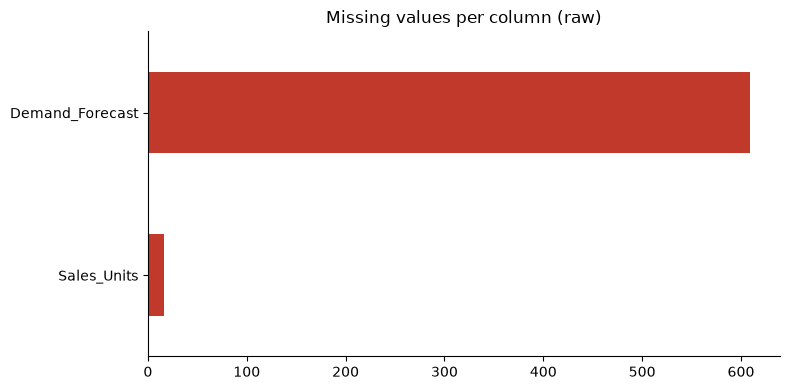

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
miss["n_missing"][miss["n_missing"] > 0].sort_values().plot.barh(ax=ax, color="#c0392b")
ax.set_title("Missing values per column (raw)"); fig.tight_layout(); fig.savefig(FIG / f"missing_values.png"); plt.show()

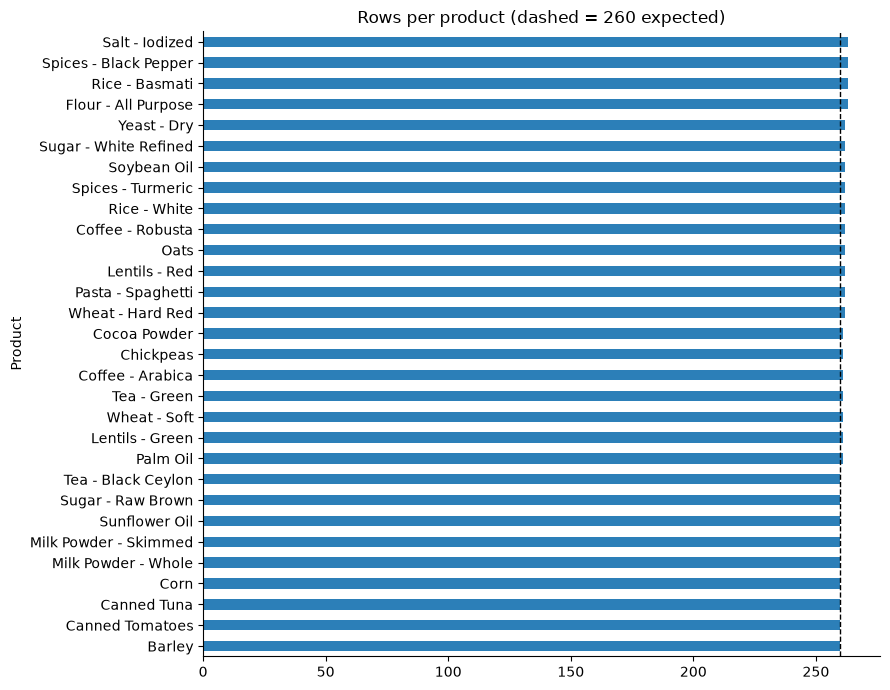

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
pc.sort_values().plot.barh(ax=ax, color="#2c7fb8"); ax.axvline(260, color="k", ls="--", lw=1)
ax.set_title("Rows per product (dashed = 260 expected)"); fig.tight_layout(); fig.savefig(FIG / f"rows_per_product.png"); plt.show()

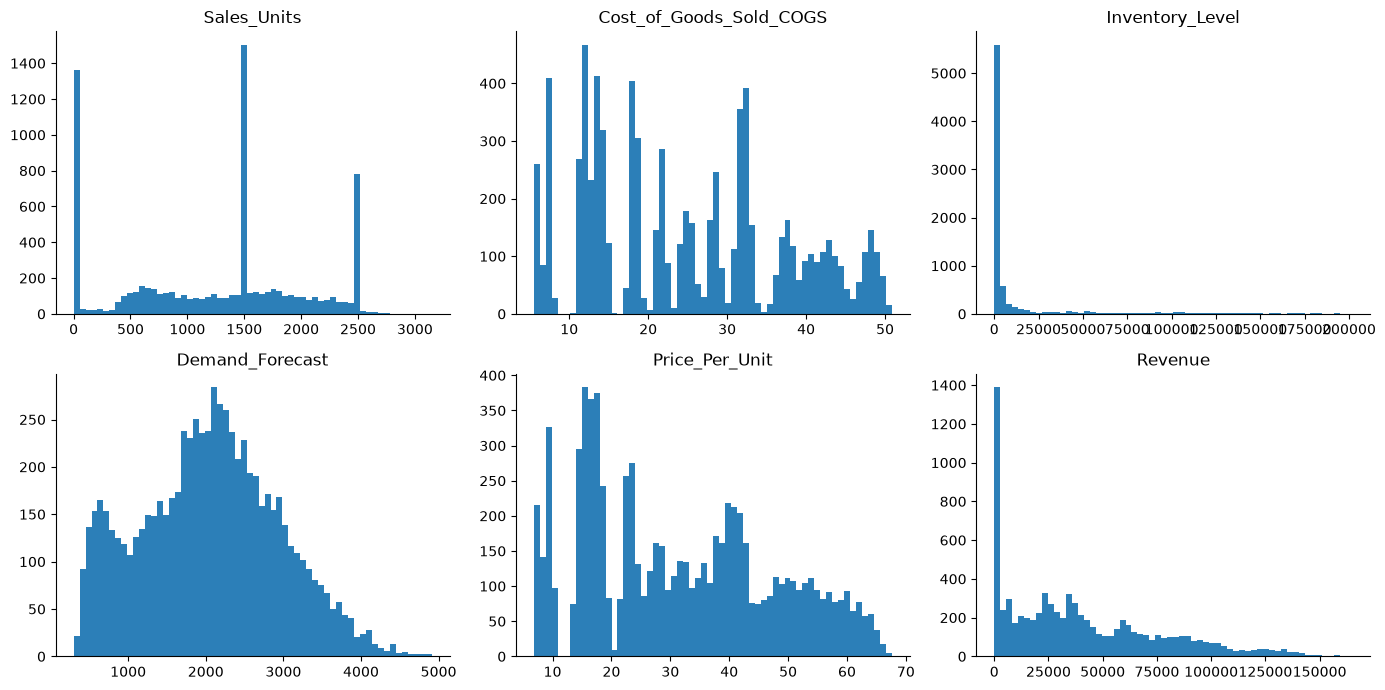

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), ["Sales_Units", "Cost_of_Goods_Sold_COGS", "Inventory_Level", "Demand_Forecast", "Price_Per_Unit", "Revenue"]):
    ax.hist(df[c].dropna(), bins=60, color="#2c7fb8"); ax.set_title(c)
fig.tight_layout(); fig.savefig(FIG / f"distributions.png"); plt.show()

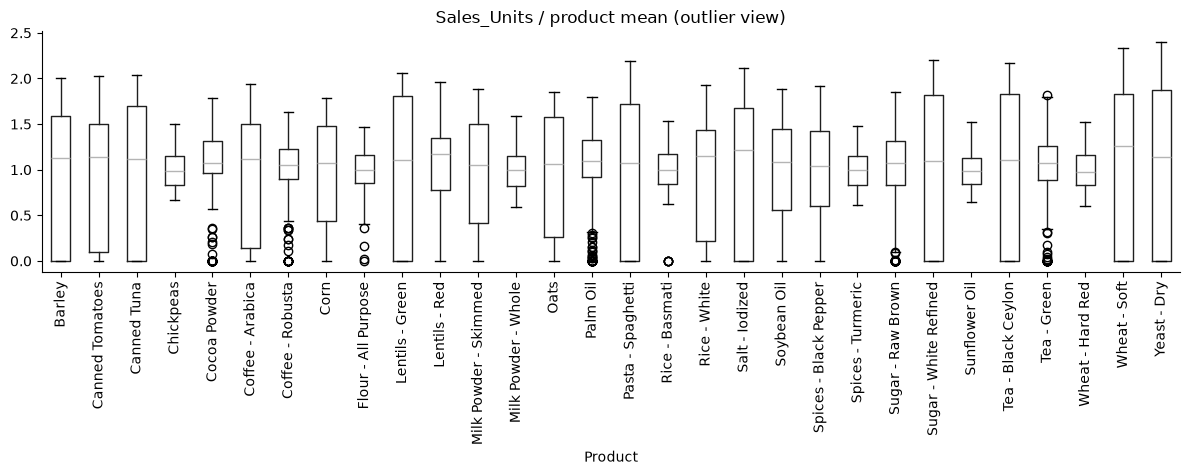

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
df.dropna(subset=["Sales_Units"]).assign(z=lambda x: x.Sales_Units / x.groupby("Product")["Sales_Units"].transform("mean")).boxplot(column="z", by="Product", ax=ax, rot=90, grid=False)
ax.set_title("Sales_Units / product mean (outlier view)"); plt.suptitle(""); fig.tight_layout(); fig.savefig(FIG / f"sales_boxplot.png"); plt.show()

first6 = df.Product.drop_duplicates().head(6)

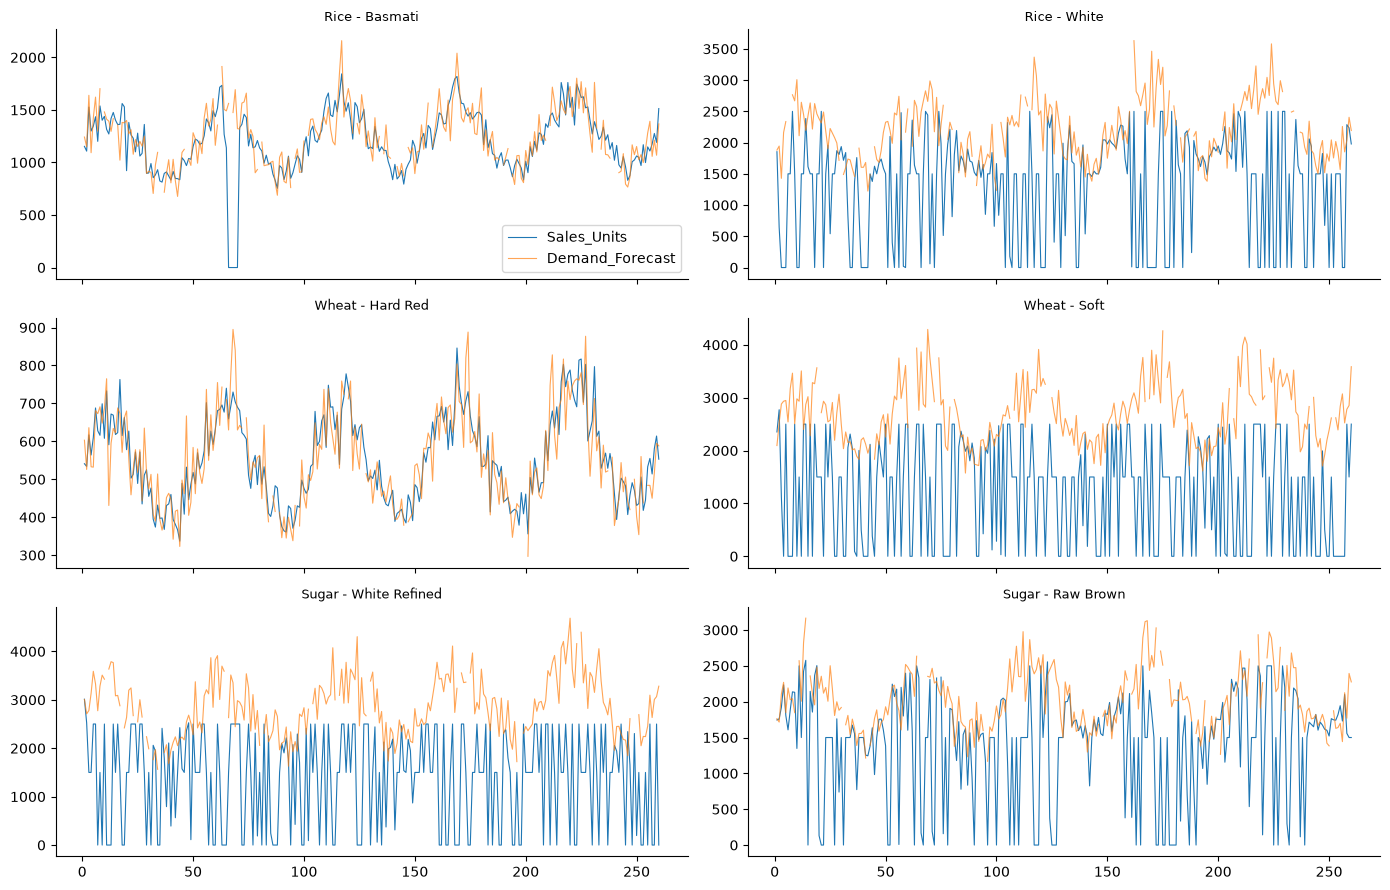

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
for ax, p in zip(axes.ravel(), first6):
    g = df[df.Product == p].sort_values("Week")
    ax.plot(g.Week, g.Sales_Units, lw=.8, label="Sales_Units"); ax.plot(g.Week, g.Demand_Forecast, lw=.8, alpha=.7, label="Demand_Forecast")
    ax.set_title(p, fontsize=9)
axes[0, 0].legend(); fig.tight_layout(); fig.savefig(FIG / f"sales_vs_forecast_sample.png"); plt.show()

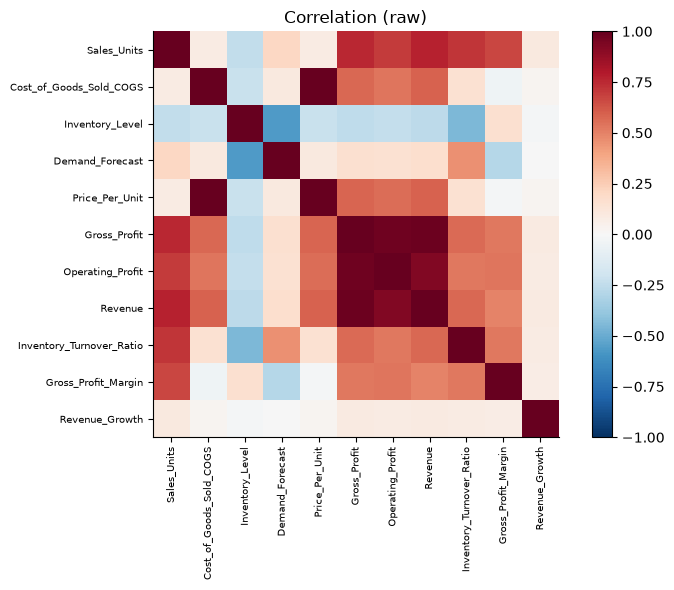

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = df[NUM].corr(); im = ax.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(NUM))); ax.set_xticklabels(NUM, rotation=90, fontsize=7); ax.set_yticks(range(len(NUM))); ax.set_yticklabels(NUM, fontsize=7)
fig.colorbar(im); ax.set_title("Correlation (raw)"); fig.tight_layout(); fig.savefig(FIG / f"correlation.png"); plt.show()

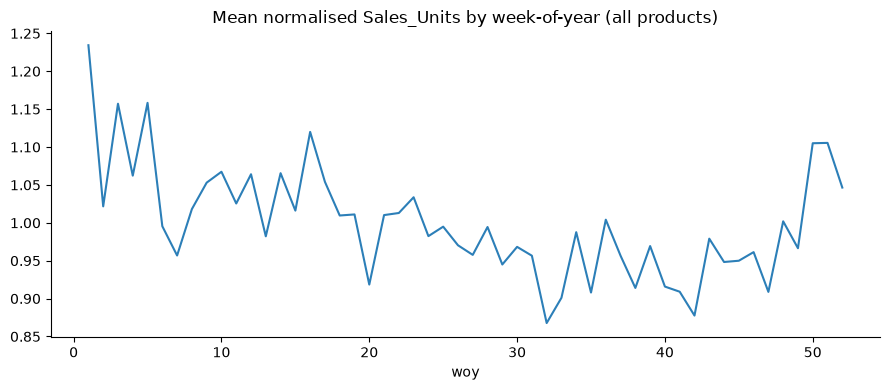

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
wk.plot(ax=ax, color="#2c7fb8"); ax.set_title("Mean normalised Sales_Units by week-of-year (all products)"); fig.tight_layout(); fig.savefig(FIG / f"seasonality.png"); plt.show()

## 14. Export to Excel
The first sheet, `Summary`, is the EDA summary (finding, severity, proposed ETL treatment); the other sheets hold the key supporting tables.

In [21]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# --- key statistics sheet -------------------------------------------------
zero = df.Sales_Units == 0
key_stats = pd.DataFrame([
    ("Rows (raw)", len(df)), ("Expected rows (30 x 260)", 30 * 260),
    ("Exact duplicate rows", int(df.duplicated().sum())),
    ("Rows after dedupe", int((~df.duplicated()).sum())),
    ("Products", df.Product.nunique()),
    ("Missing Demand_Forecast", int(df.Demand_Forecast.isna().sum())),
    ("Missing Sales_Units", int(df.Sales_Units.isna().sum())),
    ("Zero-sales rows", int(zero.sum())),
    ("Zero-sales rows with Inventory = 0", int((zero & (df.Inventory_Level == 0)).sum())),
    ("Inventory = 0 but Sales > 0", int(((df.Inventory_Level == 0) & (df.Sales_Units > 0)).sum())),
    ("Sales_Units == 2500", int((df.Sales_Units == 2500).sum())),
    ("Sales_Units == 1500", int((df.Sales_Units == 1500).sum())),
    ("Inventory_Level == 2500", int((df.Inventory_Level == 2500).sum())),
    ("Inventory_Level == 1500", int((df.Inventory_Level == 1500).sum())),
    ("Inventory_Turnover_Ratio == 1.0", int((df.Inventory_Turnover_Ratio == 1).sum())),
    ("Revenue_Growth = inf", int(np.isinf(df.Revenue_Growth).sum())),
    ("Price/COGS markup min", round((df.Price_Per_Unit / df.Cost_of_Goods_Sold_COGS).min(), 3)),
    ("Price/COGS markup max", round((df.Price_Per_Unit / df.Cost_of_Goods_Sold_COGS).max(), 3)),
], columns=["Metric", "Value"])

# --- EDA summary sheet (raw data) ----------------------------------------
n = len(df)
dup = int(df.duplicated().sum())
dd = df.drop_duplicates()
fc = RESULTS["formula_checks"].set_index("test")
ratio = df.Price_Per_Unit / df.Cost_of_Goods_Sold_COGS
fe = ((df.Demand_Forecast - df.Sales_Units).abs() / df.Sales_Units.replace(0, np.nan)).dropna()
inv_cover = (ps.inv_mean / ps.units_mean)
big = inv_cover[inv_cover > 5].sort_values(ascending=False)
wk = df.dropna(subset=["Sales_Units"]).assign(idx=lambda x: x.Sales_Units / x.groupby("Product")["Sales_Units"].transform("mean"))
season = wk.assign(woy=((wk.Week - 1) % 52) + 1).groupby("woy")["idx"].mean()

rows = [
 # (Area, Check, Result, Rows affected, Severity, Proposed treatment in ETL)
 ("Overview", "Source / shape", f"Sample_Data.xlsx, 1 sheet, {n:,} rows x {df.shape[1]} columns", n, "Info", "-"),
 ("Overview", "Grain", "One row per Product x Week; 30 products, weeks 1-260", n, "Info", "Fact grain = (product, week)"),
 ("Overview", "Expected vs actual rows", f"Expected {30*260:,}; actual {n:,}; difference {n-30*260}", n - 30*260, "Info", "-"),
 ("Completeness", "Missing Demand_Forecast", f"{int(df.Demand_Forecast.isna().sum())} rows ({df.Demand_Forecast.isna().mean():.1%}); uniform across the 5 years", int(df.Demand_Forecast.isna().sum()), "Medium", "Keep NULL + flag; legacy baseline only, do not impute"),
 ("Completeness", "Missing Sales_Units", f"{int(df.Sales_Units.isna().sum())} rows ({df.Sales_Units.isna().mean():.2%}); Revenue present in all of them", int(df.Sales_Units.isna().sum()), "High", "Recover as Revenue / Price_Per_Unit"),
 ("Completeness", "Other columns", "No missing values in the remaining 11 columns", 0, "OK", "-"),
 ("Uniqueness", "Exact duplicate rows", f"{dup} rows; all (Week, Product) key duplicates are exact copies", dup, "High", "Drop, log count in data-quality table"),
 ("Uniqueness", "Weeks per product after dedupe", f"All {dd.Product.nunique()} products have {dd.groupby('Product').Week.nunique().min()} unique weeks (complete, no gaps)", 0, "OK", "-"),
 ("Consistency", "Product names", f"{df.Product.nunique()} distinct names; no case / whitespace variants", 0, "OK", "Still trim/normalise in ETL"),
 ("Consistency", "Revenue = Sales x Price", f"{fc.loc['Revenue = Sales*Price','pct_within_1%_rel']}% match", 0, "OK", "Recompute in ETL"),
 ("Consistency", "Gross_Profit = Revenue - Sales x COGS", f"{fc.loc['Gross_Profit = Revenue - Sales*COGS','pct_within_1%_rel']}% match", 0, "OK", "Recompute in ETL"),
 ("Consistency", "Gross_Profit_Margin = GP / Revenue", f"{fc.loc['GPM = GP/Revenue','pct_within_1%_rel']}% match (where Revenue > 0)", 0, "OK", "Recompute; NULL when Revenue = 0"),
 ("Consistency", "Revenue_Growth", f"{int(np.isinf(df.Revenue_Growth).sum())} inf values (growth after a zero-revenue week); {fc.loc['Rev_Growth = pct_change(Revenue)','pct_within_1%_rel']}% equal week-over-week change", int(np.isinf(df.Revenue_Growth).sum()), "High", "Replace inf with NULL; recompute from clean revenue"),
 ("Consistency", "Inventory_Turnover_Ratio", f"Matches neither Sales/Inventory ({fc.loc['Turnover = Sales/Inventory','pct_within_1%_rel']}%) nor Sales x COGS/Inventory ({fc.loc['Turnover = Sales*COGS/Inventory','pct_within_1%_rel']}%); clipped at 1.0 in {int((df.Inventory_Turnover_Ratio==1).sum()):,} rows", int((df.Inventory_Turnover_Ratio == 1).sum()), "Medium", "Document own definition (COGS sold / inventory) and recompute"),
 ("Consistency", "Operating_Profit", f"Always <= Gross_Profit ({int((df.Operating_Profit > df.Gross_Profit).sum())} violations); opex not provided so not reproducible", 0, "Info", "Keep as given; derive implied opex = GP - OP"),
 ("Validity", "Zero-sales weeks", f"{int((df.Sales_Units==0).sum()):,} rows ({(df.Sales_Units==0).mean():.1%}); Revenue = GP = 0; runs median 1 wk, max 6; only {int(((df.Sales_Units==0)&(df.Inventory_Level==0)).sum())} have Inventory = 0", int((df.Sales_Units == 0).sum()), "High", "Flag as probable censored demand (is_zero_sales); handle explicitly in forecasting"),
 ("Validity", "Inventory = 0 but Sales > 0", f"{int(((df.Inventory_Level==0)&(df.Sales_Units>0)).sum())} rows (logically impossible)", int(((df.Inventory_Level == 0) & (df.Sales_Units > 0)).sum()), "High", "Flag (inventory_inconsistent); do not delete"),
 ("Validity", "Inventory clipped", f"Spikes at 0 ({int((df.Inventory_Level==0).sum()):,}), 1,500 ({int((df.Inventory_Level==1500).sum()):,}) and 2,500 ({int((df.Inventory_Level==2500).sum()):,}) rows", int(df.Inventory_Level.isin([0, 1500, 2500]).sum()), "Medium", "Flag (is_capped); keep values"),
 ("Validity", "Sales_Units capped", f"Value 2,500 in {int((df.Sales_Units==2500).sum())} rows, 1,500 in {int((df.Sales_Units==1500).sum()):,} rows", int(df.Sales_Units.isin([1500, 2500]).sum()), "Medium", "Flag (is_capped); right-censored demand"),
 ("Validity", "Negative values / price < COGS", f"{int((df[NUM].select_dtypes('number') < 0).sum().drop('Revenue_Growth').sum())} negatives (excl. Revenue_Growth); {int((df.Price_Per_Unit < df.Cost_of_Goods_Sold_COGS).sum())} rows with price < COGS", 0, "OK", "Add as validation rules"),
 ("Outliers", "Sales_Units (per-product robust z > 4)", f"{int(RESULTS['outlier_counts'].set_index('column').loc['Sales_Units','robust_z>4'])} rows", int(RESULTS['outlier_counts'].set_index('column').loc['Sales_Units', 'robust_z>4']), "Low", "Flag; winsorise only if confirmed anomalous"),
 ("Outliers", "High-stock products", f"{len(big)} products with > 5 weeks of cover: " + ", ".join(f"{p} ({v:.0f} wks)" for p, v in big.items()), int(df.Product.isin(big.index).sum()), "Info", "Do NOT treat as errors; real inventory-risk cases for dashboard/pricing"),
 ("Business signal", "Price / COGS markup", f"Uniform {ratio.min():.2f}-{ratio.max():.2f} for all products", 0, "Info", "Little pricing signal; elasticity must be inferred carefully"),
 ("Business signal", "Existing Demand_Forecast vs actual", f"Correlation {df.Demand_Forecast.corr(df.Sales_Units):.2f}; median abs % error {fe.median():.1%} (non-zero sales rows)", 0, "Info", "Use as benchmark / feature only"),
 ("Business signal", "Seasonality / trend", f"Weak seasonal index {season.min():.2f}-{season.max():.2f}; flat trend years 1-4, ~+4% in year 5", 0, "Info", "Include week-of-year and trend features"),
]
summary = pd.DataFrame(rows, columns=["Area", "Check", "Result", "Rows affected", "Severity", "Proposed treatment"])
summary.insert(0, "#", range(1, len(summary) + 1))
findings = summary

# --- write workbook -------------------------------------------------------
XLSX = OUT / f"v1_eda_results.xlsx"
KEEP = ["Summary", "Key_Stats", "missing_values", "duplicate_rows", "outlier_counts", "top_outliers", "formula_checks", "product_summary"]
sheets_all = {"Summary": summary, "Key_Stats": key_stats, **RESULTS}
sheets = {k: sheets_all[k] for k in KEEP}
with pd.ExcelWriter(XLSX, engine="openpyxl") as xw:
    for name, t in sheets.items():
        t.to_excel(xw, sheet_name=name[:31], index=False)

wb = load_workbook(XLSX)
head_fill = PatternFill("solid", fgColor="1F4E79")
for ws in wb.worksheets:
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF"); cell.fill = head_fill
        cell.alignment = Alignment(horizontal="center", vertical="center")
    ws.freeze_panes = "A2"
    for i, col in enumerate(ws.columns, 1):
        width = max(len(str(c.value)) if c.value is not None else 0 for c in list(col)[:200])
        ws.column_dimensions[get_column_letter(i)].width = min(max(width + 2, 10), 90)
ws = wb["Summary"]
for col, w in zip("ABCDEFG", [5, 16, 38, 90, 14, 10, 62]):
    ws.column_dimensions[col].width = w
sev = {"High": "F8CBAD", "Medium": "FFE699", "Low": "DDEBF7", "OK": "C6E0B4", "Info": "EDEDED"}
for r in ws.iter_rows(min_row=2):
    for c in r:
        c.alignment = Alignment(wrap_text=True, vertical="top")
    r[5].fill = PatternFill("solid", fgColor=sev.get(r[5].value, "FFFFFF"))
    r[4].number_format = "#,##0"

wb.save(XLSX)
print("Saved:", XLSX, "| sheets:", wb.sheetnames)

Saved: /home/user/Technical_Assessment_HamidrezaNademi/part1_eda/v1_eda_results.xlsx | sheets: ['Summary', 'Key_Stats', 'missing_values', 'duplicate_rows', 'outlier_counts', 'top_outliers', 'formula_checks', 'product_summary']


## 15. Key findings (see the `Summary` sheet in the Excel file for the full table)
| Area | Finding |
|---|---|
| Size / duplicates | 7,839 rows vs 7,800 expected; 39 exact duplicate rows; after dedupe every product has 260 weeks, no gaps |
| Product names | 30 clean names, no variants |
| Missing | `Demand_Forecast` 609 (7.8%); `Sales_Units` 16 (recoverable as `Revenue / Price_Per_Unit`) |
| Zero sales | 1,333 rows (17%), short runs; only 431 coincide with Inventory = 0 |
| Inventory | Clipped at 0 / 1,500 / 2,500; 905 rows have Inventory = 0 but Sales > 0 |
| Caps | `Sales_Units` at 1,500 / 2,500; Turnover clipped at 1.0 in 2,842 rows |
| Derived columns | Revenue, Gross_Profit, GPM reproduce 100%; Revenue_Growth has 897 `inf`; Turnover formula unknown; Operating_Profit not reproducible |
| Pricing | Price / COGS markup uniformly 1.20–1.35 |
| Baseline forecast | corr 0.21 with actual sales, median abs error 17.5% |
| Seasonality | weak (index 0.87–1.23) |